# Syriac width jitter preview

Pick one train line, scale it to Calamari height 48, then show `scale_line_width` at 0.5 / 1.0 / 2.0 and a few random `jitter_syriac_line_width` draws. Height stays 48; only width changes.

syriac_2025_0002436.jpg
GT: ܘܛܝܒܘܬܐ ܚܠܦ ܛܝܒܘܬܐ܁
model tensor: (252, 48, 1) (width, height, 1)



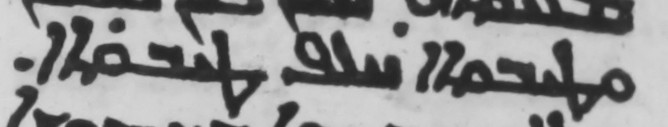


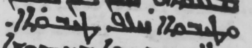

In [1]:
from __future__ import annotations

import io
import random
import sys
from pathlib import Path

import numpy as np
from IPython.display import HTML, display
from PIL import Image as PILImage

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError("Could not locate the greek-ocr repo root.")

REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.models.calamari.augmentation import jitter_syriac_line_width, scale_line_width
from src.models.calamari.data import _load_line_image

DATA = REPO / "data" / "processed" / "syriac" / "pretraining"
LINE_HEIGHT = 48
SEED = 2026


def tensor_to_pil(image) -> PILImage.Image:
    pixels = image.squeeze(-1).detach().cpu().numpy()
    pixels = np.clip(pixels, 0, 255).astype(np.uint8).T
    return PILImage.fromarray(pixels, mode="L")


def png_data_uri(pil: PILImage.Image) -> str:
    buffer = io.BytesIO()
    pil.save(buffer, format="PNG")
    import base64

    return "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")


def show_row(title: str, items: list[tuple[str, object]]) -> None:
    cells = []
    for label, image in items:
        pil = tensor_to_pil(image)
        w, h = pil.size
        cells.append(
            "<div style='margin:0 12px 12px 0'>"
            f"<div style='font:12px/1.4 monospace;margin-bottom:6px'>{label}<br>{w}×{h} px</div>"
            f"<img src='{png_data_uri(pil)}' style='height:48px;image-rendering:pixelated;"
            "border:1px solid #ccc;background:#fff'/>"
            "</div>"
        )
    display(HTML(f"<h3>{title}</h3><div style='display:flex;flex-wrap:wrap;align-items:flex-end'>{''.join(cells)}</div>"))


rows = []
for line in (DATA / "gt_train.txt").read_text(encoding="utf-8").splitlines():
    name, text = line.split("\t", 1)
    if name.startswith("syriac_2025_") and 12 <= len(text) <= 24:
        rows.append((name, text))

rng = random.Random(SEED)
name, text = rng.choice(rows)
path = DATA / "image" / name
model_image = _load_line_image(path, LINE_HEIGHT)
print(f"{name}\nGT: {text}\nmodel tensor: {tuple(model_image.shape)} (width, height, 1)")
display(HTML(f"<p><b>Original crop</b></p><img src='{png_data_uri(PILImage.open(path).convert('L'))}' style='max-width:100%;border:1px solid #ccc'/>"))
show_row("After Calamari scale-to-height 48 (input to jitter)", [("scale-to-height", model_image)])



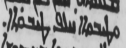
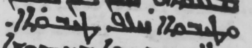
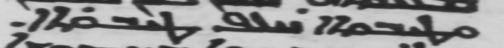

In [2]:
show_row(
    "scale_line_width (fixed factors)",
    [
        ("0.5× compress", scale_line_width(model_image, 0.5)),
        ("1.0× unchanged", scale_line_width(model_image, 1.0)),
        ("2.0× stretch", scale_line_width(model_image, 2.0)),
    ],
)



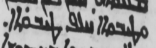
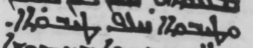
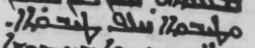
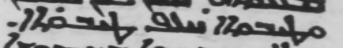
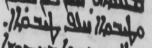
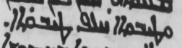

In [3]:
random.seed(SEED)
jittered = []
for i in range(6):
    out = jitter_syriac_line_width(model_image)
    scale = out.shape[0] / model_image.shape[0]
    jittered.append((f"draw {i + 1}: {scale:.2f}×", out))
show_row("jitter_syriac_line_width (uniform 0.5–2.0, six draws)", jittered)


## Saved preview (`syriac_2025_0002437.jpg`)

GT: `ܡܛܠ ܕܢܡܘܣܐ ܒܝܕ ܡܘܫܐ`

**Original crop**

![original](syriac_width_jitter/original.png)

**After Calamari scale-to-height 48**

![height48](syriac_width_jitter/height48.png)

**`scale_line_width` at 0.5× / 1.0× / 2.0×** (height stays 48)

![scale](syriac_width_jitter/scale_line_width.png)

**Six random `jitter_syriac_line_width` draws** (uniform 0.5–2.0)

![jitter](syriac_width_jitter/jitter_syriac_line_width.png)